## Imports

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.tools import (
    extract_clean_segments,
    compute_lagged_correlations,
    find_dominant_lagged_pairs,
    print_dominant_pairs,
    plot_pearson_heatmap,
    report_correlation_distribution,
    classify_anomalies,
    summarize,
    collect_seg_stats,
    plot_threshold_sensitivity,
    preceding_normal_context,
    max_z_score,
    max_delta_rho_lagged,
    find_contiguous_segments,
    compute_univariate_intensity,
    plot_univariate_intensity_distribution
)

## Loading

Source : https://zenodo.org/records/3884398

In [2]:
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'datasets').is_dir())

path = PROJECT_ROOT / 'datasets' / 'gecco'
print("Path to dataset files:", path)    

Path to dataset files: /home/roux/projects/first-paper/datasets/gecco


In [3]:
print("Contents of the dataset directory:", os.listdir(path))
os.listdir(path)

Contents of the dataset directory: ['1_gecco2018_water_quality.csv']


['1_gecco2018_water_quality.csv']

In [4]:
df = pd.read_csv(os.path.join(path, "1_gecco2018_water_quality.csv"))

## Basic infos

In [5]:
df.describe()

,Unnamed: 0,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2
count,139566.000000,138522.000000,138521.000000,138522.000000,138522.000000,138522.000000,138522.000000,138522.000000,138522.000000,138522.000000
mean,69783.500000,8.521406,0.165482,8.366416,752.899009,209.520998,0.019778,0.106099,1534.208891,927.728014
std,40289.378172,1.281314,0.010207,0.101624,12.945284,7.747497,0.005492,0.007132,208.171011,147.447430
min,1.000000,0.000000,0.000000,4.000000,300.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34892.250000,7.500000,0.160000,8.340000,751.000000,209.000000,0.016000,0.103000,1388.000000,847.000000
50%,69783.500000,8.400000,0.170000,8.370000,754.000000,211.000000,0.018000,0.106000,1512.000000,925.000000
75%,104674.750000,9.500000,0.170000,8.390000,756.000000,211.000000,0.023000,0.110000,1650.000000,1000.000000
max,139566.000000,11.800000,0.800000,8.936228,895.000000,646.000000,0.254000,0.462000,3923.000000,2592.000000


In [6]:
df.head()

,Unnamed: 0,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
0,1,2016-08-03 11:49:00,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1677.0,695.0,False
1,2,2016-08-03 11:50:00,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1561.0,696.0,False
2,3,2016-08-03 11:51:00,6.5,0.17,8.35,749.0,211.0,0.011,0.117,1581.0,696.0,False
3,4,2016-08-03 11:52:00,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1579.0,693.0,False
4,5,2016-08-03 11:53:00,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1567.0,689.0,False


In [7]:
# Remove first column (it's just the row counter)
df = df.iloc[:, 1:]

In [8]:
df.head()

,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
0,2016-08-03 11:49:00,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1677.0,695.0,False
1,2016-08-03 11:50:00,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1561.0,696.0,False
2,2016-08-03 11:51:00,6.5,0.17,8.35,749.0,211.0,0.011,0.117,1581.0,696.0,False
3,2016-08-03 11:52:00,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1579.0,693.0,False
4,2016-08-03 11:53:00,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1567.0,689.0,False


## Data exploration

In [9]:
# Check if there is any missing values in the training data
df.isnull().sum()

Time        0
Tp       1044
Cl       1045
pH       1044
Redox    1044
Leit     1044
Trueb    1044
Cl_2     1044
Fm       1044
Fm_2     1044
EVENT       0
dtype: int64

In [10]:
# Check if timestep is constant
time_diffs = df.index.to_series().diff().dropna()
print(time_diffs.unique())

[1.]


In [11]:
print("Number of entries:", len(df))
print("Number of entries without NA:", len(df.dropna()))

Number of entries: 139566
Number of entries without NA: 138521


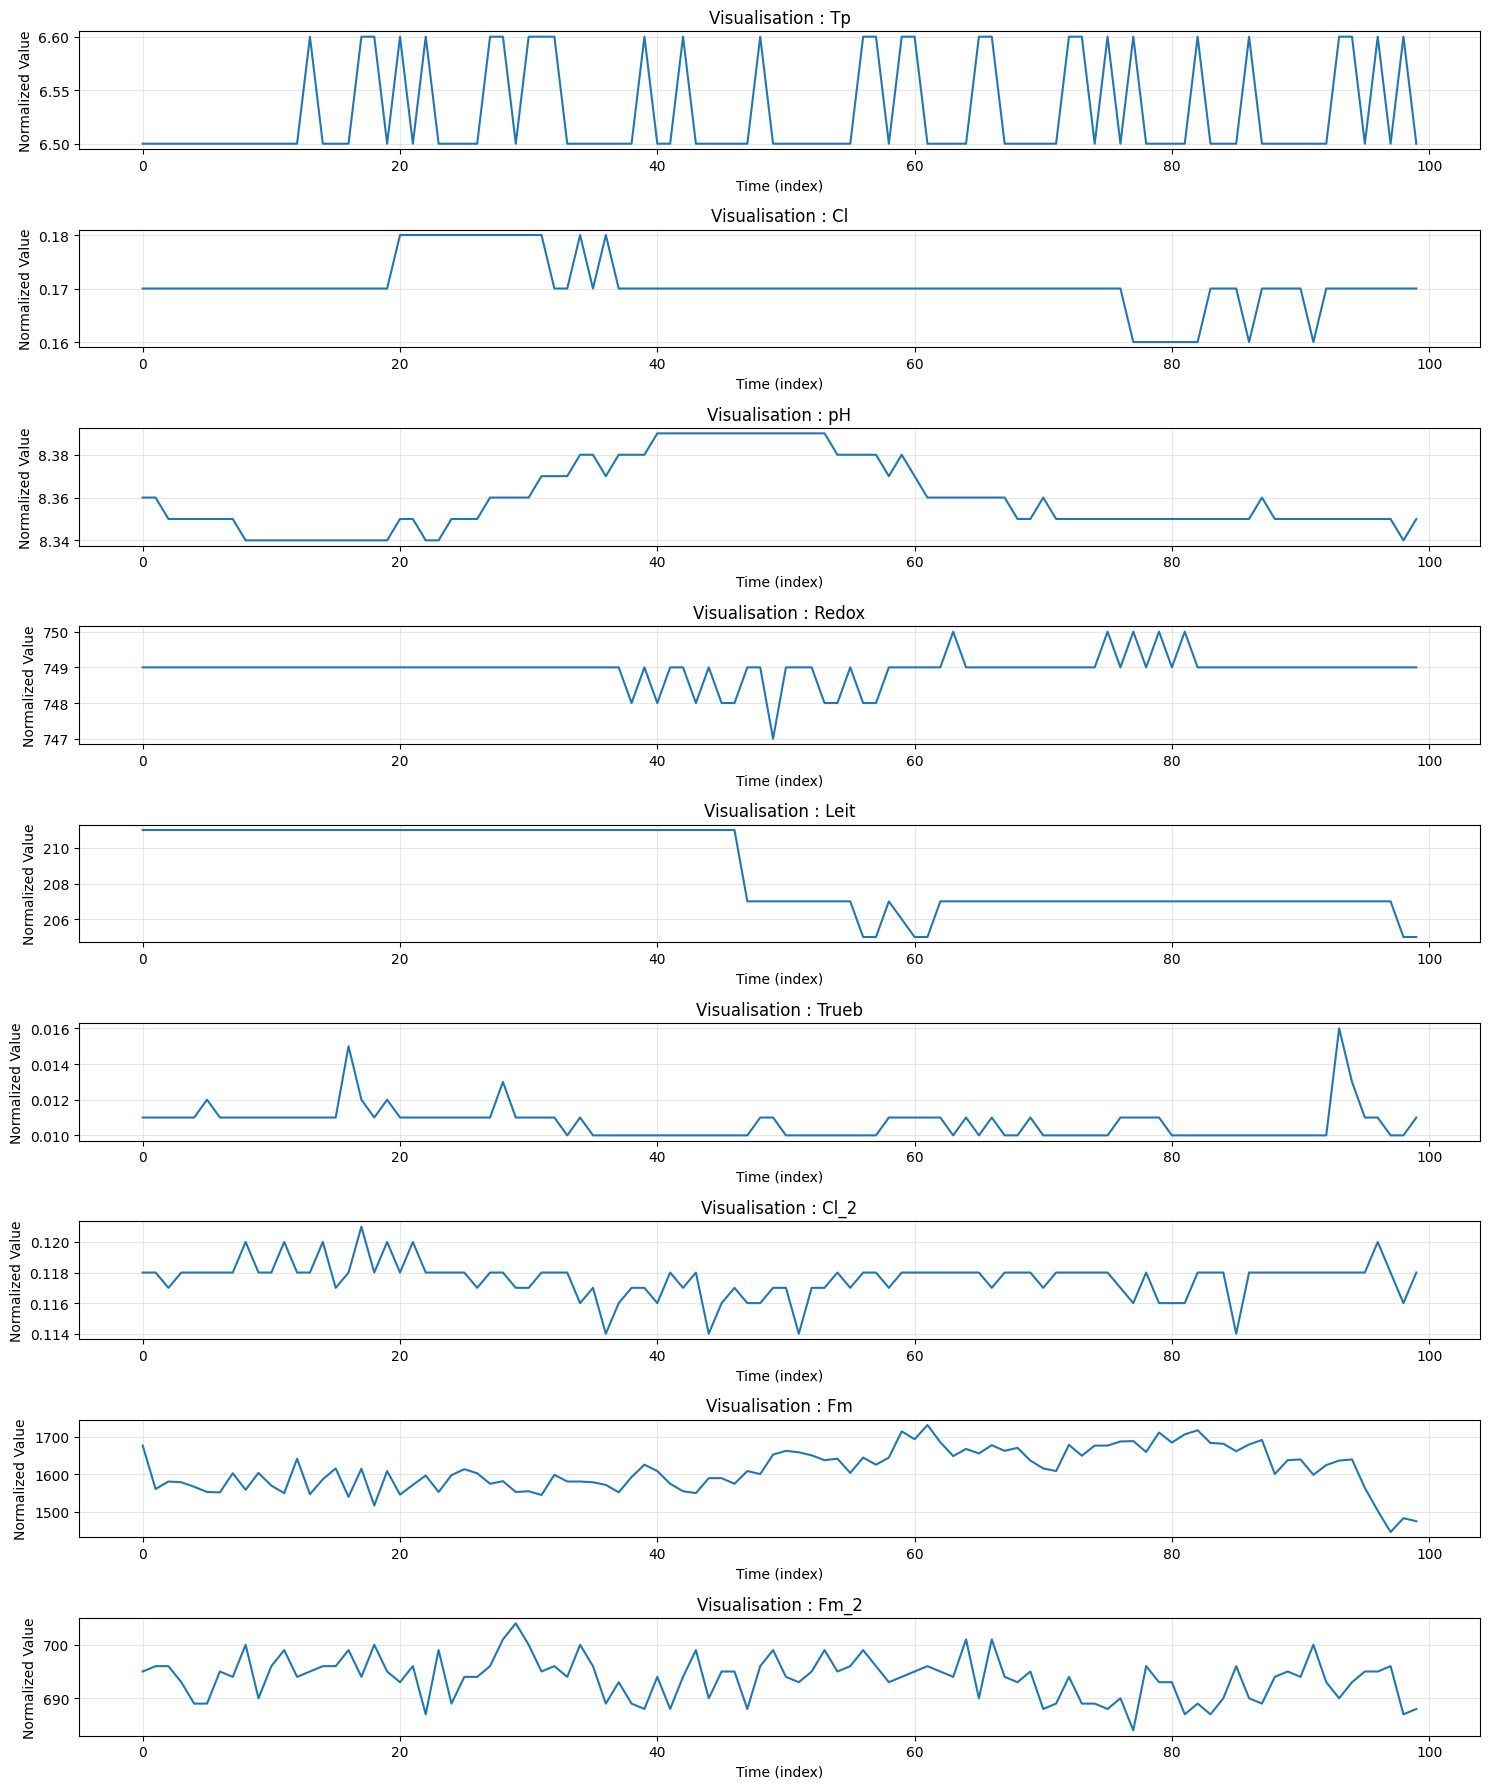

In [12]:
features_to_plot = [f for f in df.columns if "time" not in f.lower() and "event" not in f.lower()]
num_features = len(features_to_plot)

plt.figure(figsize=(15, num_features * 2))

for i, feature in enumerate(features_to_plot):
    plt.subplot(num_features, 1, i + 1)
    plt.plot(df[feature][:100])
    
    plt.title(f"Visualisation : {feature}")
    plt.xlabel('Time (index)')
    plt.ylabel('Normalized Value')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Minimal preprocessing

Replicating **CrossAD: Time Series Anomaly Detection with Cross-scale Associations and Cross-window Modeling** (Li et al., NeurIPS 2025), link [here](https://arxiv.org/pdf/2510.12489).

In [13]:
print("Unique values in 'event' column:", df['EVENT'].unique())

df = df.drop(columns=['Time'])
df.head()

Unique values in 'event' column: [False  True]


,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
0,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1677.0,695.0,False
1,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1561.0,696.0,False
2,6.5,0.17,8.35,749.0,211.0,0.011,0.117,1581.0,696.0,False
3,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1579.0,693.0,False
4,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1567.0,689.0,False


In [14]:
# Delete all rows with null/nan values
df = df.dropna()

In [15]:
# Split data into features and labels
x = df.drop(columns=['EVENT'])
y = df['EVENT']

print(x.head(n=3))
print(y.head(n=3))

    Tp    Cl    pH  Redox   Leit  Trueb   Cl_2      Fm   Fm_2
0  6.5  0.17  8.36  749.0  211.0  0.011  0.118  1677.0  695.0
1  6.5  0.17  8.36  749.0  211.0  0.011  0.118  1561.0  696.0
2  6.5  0.17  8.35  749.0  211.0  0.011  0.117  1581.0  696.0
0    False
1    False
2    False
Name: EVENT, dtype: bool


In [16]:
# Count number of null/nan entries
print("Number of null/nan entries in x:", x.isnull().sum().sum())
print("Number of null/nan entries in y:", y.isnull().sum())

Number of null/nan entries in x: 0
Number of null/nan entries in y: 0


In [17]:
# Count number of rows in x and y
print("Number of rows in x:", len(x))
print("Number of rows in y:", len(y))

Number of rows in x: 138521
Number of rows in y: 138521


## Exemple of good initialization practice

x_train, x_val, x_test, y_train, y_val, y_test (no data leakage, no shuffling, etc.)

In [18]:
# Split x and y into train, val, test (50% train, 50% test, 80/20 split for train/val)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=42, shuffle=False)  # CrossAD splits 50/50 train and test
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, shuffle=False)  # CrossAD splits 80/20 train and val

print("Number of rows in x_train:", len(x_train))
print("Number of rows in y_train:", len(y_train))
print("Number of rows in x_val:", len(x_val))
print("Number of rows in y_val:", len(y_val))
print("Number of rows in x_test:", len(x_test))
print("Number of rows in y_test:", len(y_test))

Number of rows in x_train: 55408
Number of rows in y_train: 55408
Number of rows in x_val: 13852
Number of rows in y_val: 13852
Number of rows in x_test: 69261
Number of rows in y_test: 69261


In [19]:
anomaly_ratio = y.mean()
print(f"Anomaly ratio in the whole dataset: {anomaly_ratio * 100:.2f}%")

Anomaly ratio in the whole dataset: 1.25%


# Correlation analysis between channels on normal data

We remove anomalies from train to keep only normal data

(yes, GECCO has anomalies in train)

In [20]:
train_full = df.iloc[:len(df)//2]  # CrossAD splits 50/50 train and test, so train is the first half of the dataset
mask_normal = train_full['EVENT'] == 0
train_normal = train_full[mask_normal]
print(f"Train total: {len(train_full)}, normal: {len(train_normal)}, removed anomalies: {(~mask_normal).sum()}")

x_train_clean = train_normal.drop(columns=['EVENT'])

Train total: 69260, normal: 68264, removed anomalies: 996


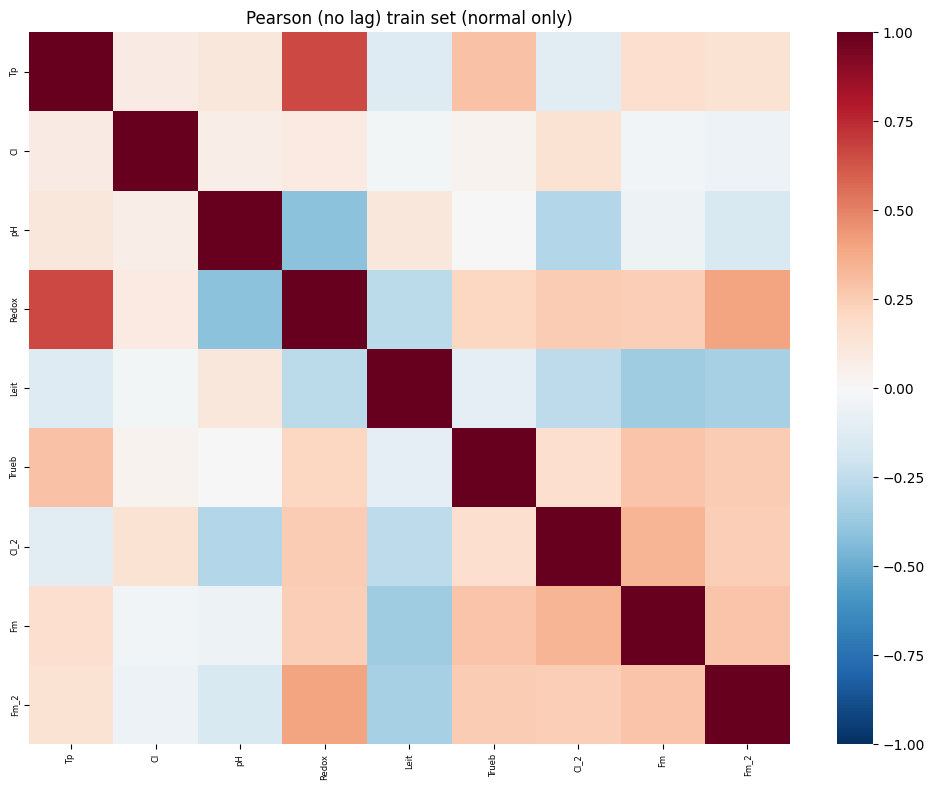

In [21]:
x_train_clean = train_normal.drop(columns=['EVENT'])
features = x_train_clean.columns.tolist()

pearson_matrix = x_train_clean.corr(method='pearson').values
plot_pearson_heatmap(pearson_matrix, features, title="Pearson (no lag) train set (normal only)", figsize=(10, 8))

In [22]:
print("|r| distribution (without the diagonal):")
report_correlation_distribution(pearson_matrix)

|r| distribution (without the diagonal):
Total pairs: 36
  Pairs with |r| > 0.3: 6/36 (16.7%)
  Pairs with |r| > 0.5: 1/36 (2.8%)
  Pairs with |r| > 0.7: 0/36 (0.0%)


In [23]:
max_lag = 128  # CrossAD uses a sliding window of 128 for GECCO

features_array = train_full.drop(columns=['EVENT']).values
segments = extract_clean_segments(features_array, mask_normal.values, max_lag=max_lag)
if not segments:
    raise ValueError(f"No segments found that satisfy >= {2 * max_lag}")

seg_lengths = list(map(len, segments))
print(f"Segments (L >= {2 * max_lag}): {len(segments)} | min={min(seg_lengths)}, max={max(seg_lengths)}, total={sum(seg_lengths)}")
print(f"Ratio of kept points after segmentation: {sum(seg_lengths)}/{len(train_full)} ({sum(seg_lengths)/len(train_full)*100:.1f}%)")

Segments (L >= 256): 18 | min=270, max=21195, total=65923
Ratio of kept points after segmentation: 65923/69260 (95.2%)


Segments (Spearman): 100%|██████████| 18/18 [00:00<00:00, 30.80it/s]


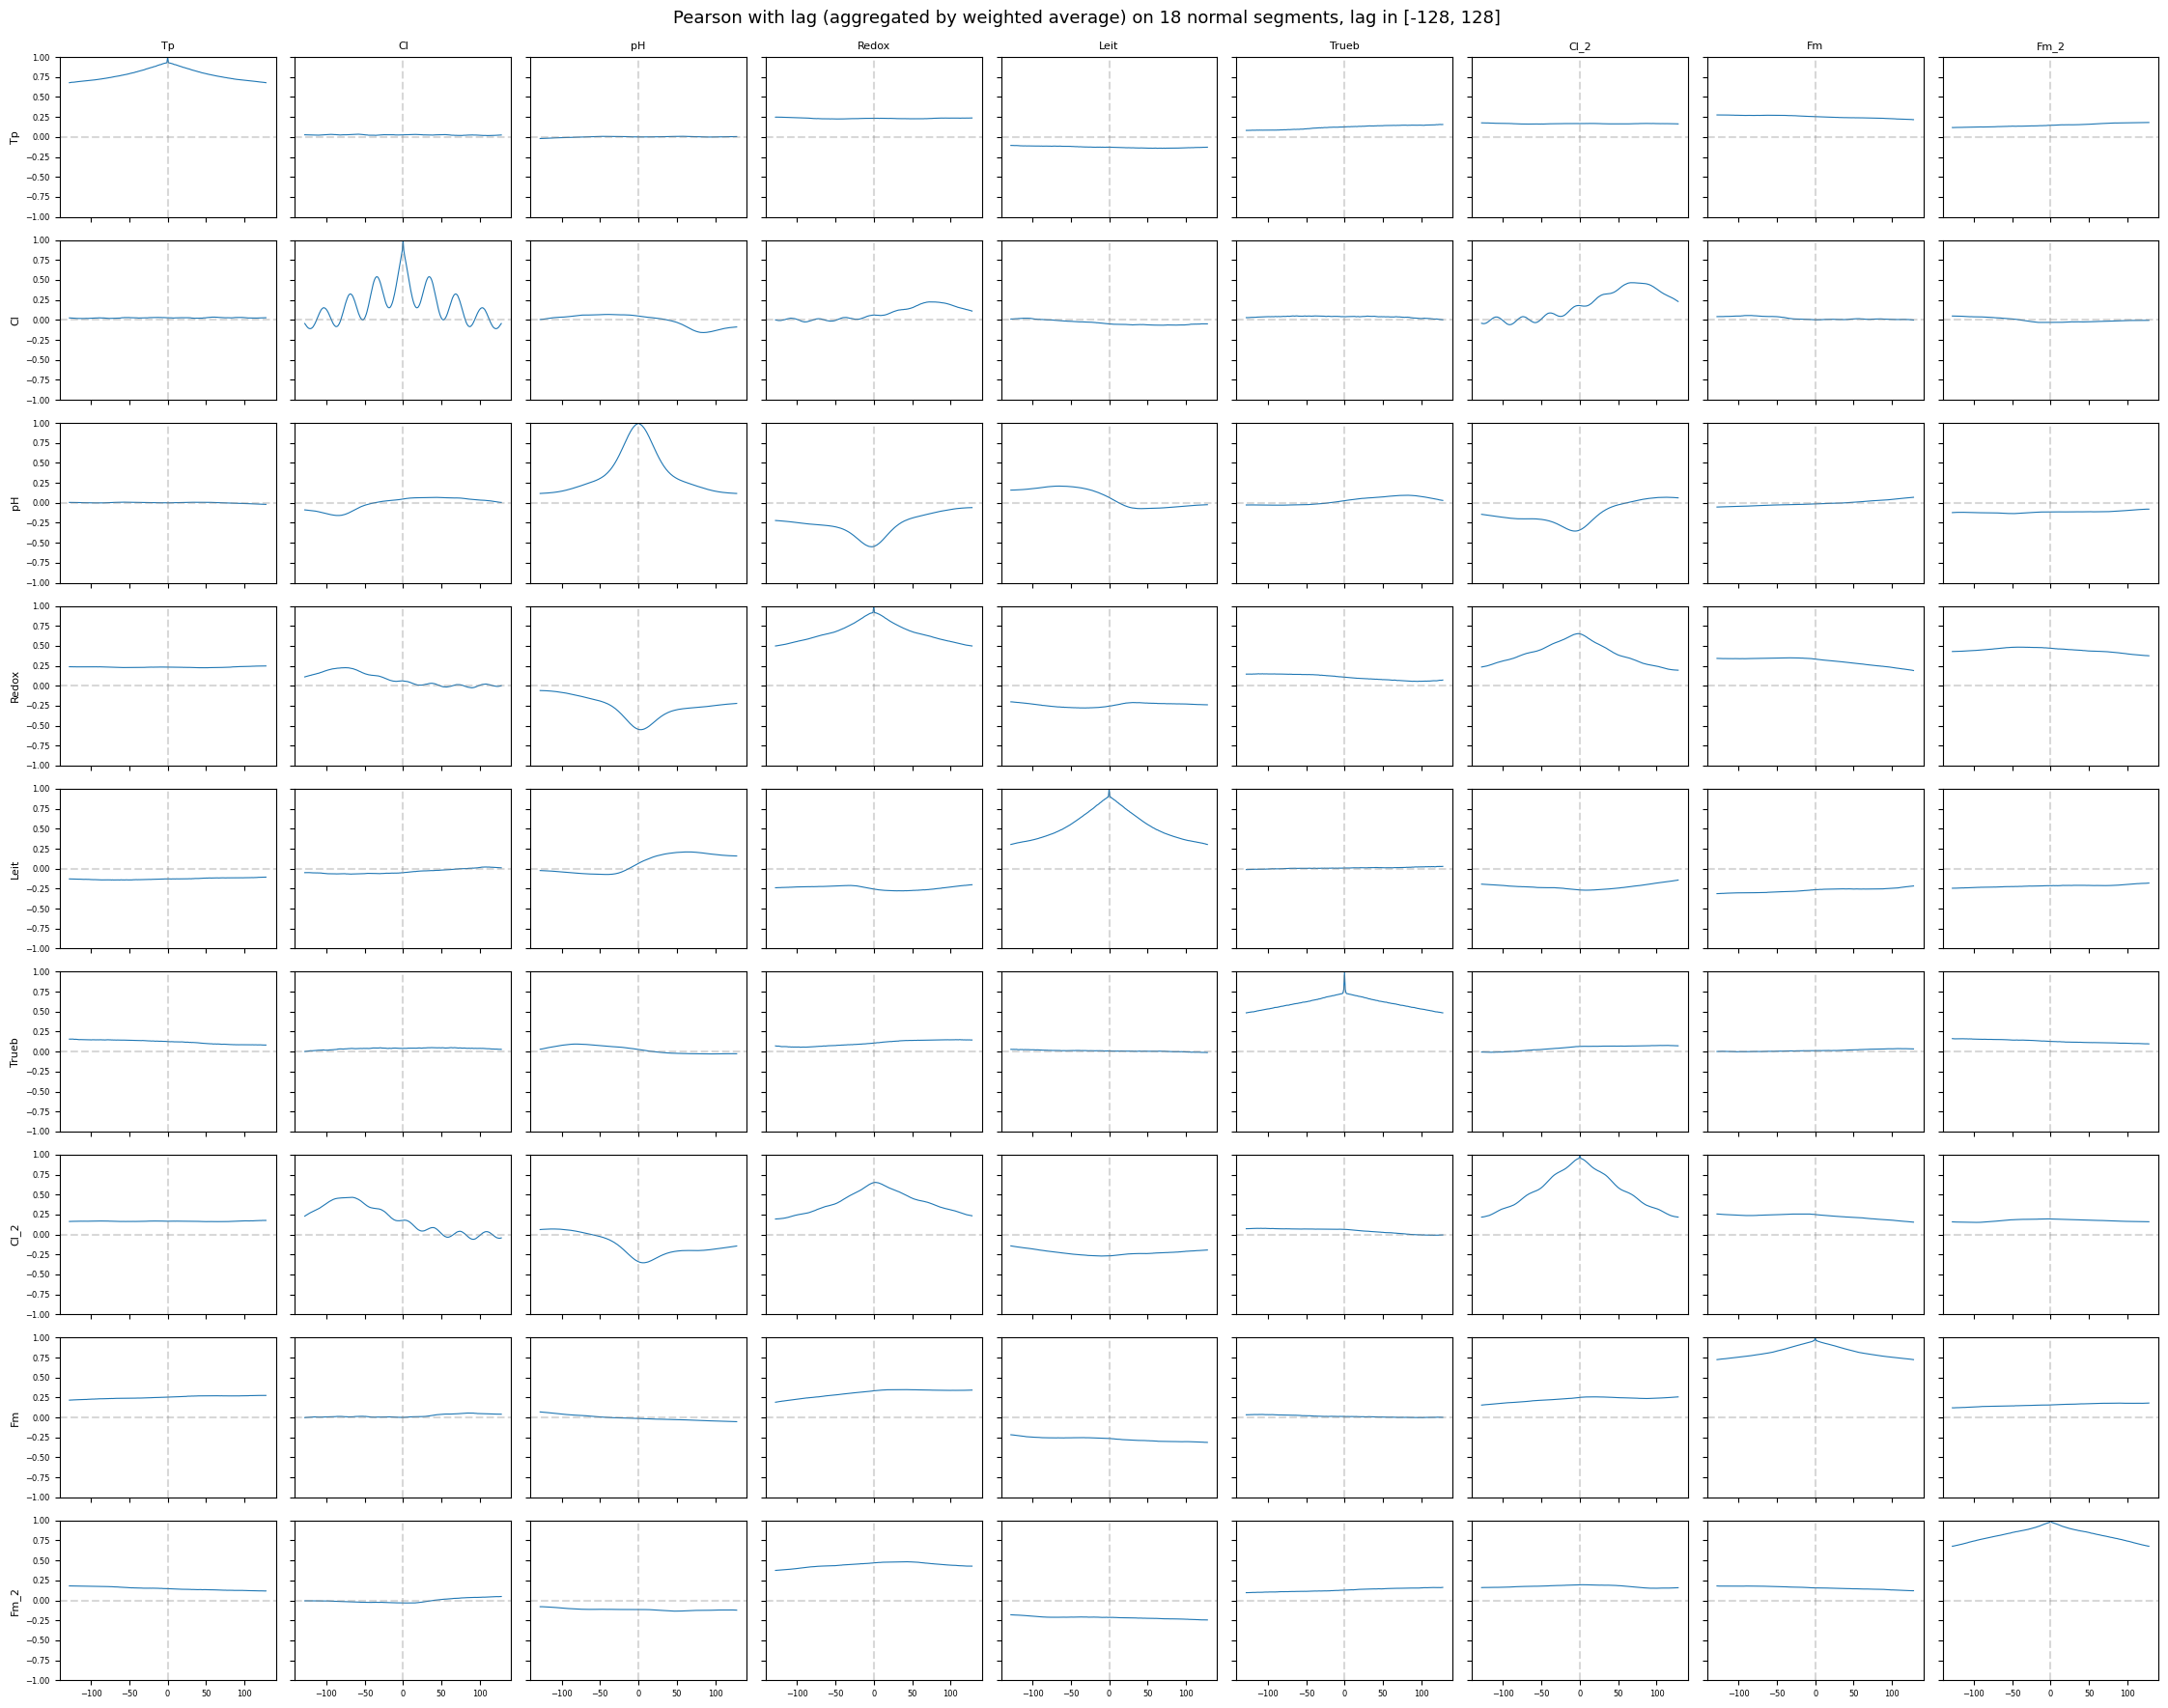

In [24]:
lagged_corrs = compute_lagged_correlations(segments, max_lag=max_lag)

lagged_pearson = lagged_corrs['pearson']
C = lagged_pearson.shape[0]
features = train_full.drop(columns=['EVENT']).columns.tolist()
lag_range = np.arange(-max_lag, max_lag + 1)

fig, axes = plt.subplots(C, C, figsize=(2.5*C, 2*C), sharex=True, sharey=True)
for (i, j), ax in np.ndenumerate(axes):
    ax.plot(lag_range, lagged_pearson[i, j, :], linewidth=0.8)
    ax.axhline(0, color='gray', ls='--', alpha=0.3)
    ax.axvline(0, color='gray', ls='--', alpha=0.3)
    ax.set_ylim(-1, 1)
    if i == 0: ax.set_title(features[j], fontsize=8)
    if j == 0: ax.set_ylabel(features[i], fontsize=8)
    ax.tick_params(labelsize=6)
plt.suptitle(f"Pearson with lag (aggregated by weighted average) on {len(segments)} normal segments, lag in [{-max_lag}, {max_lag}]\n", fontsize=13)
plt.tight_layout()
plt.show()

r between per-segment means (Tp, Redox) = +0.843


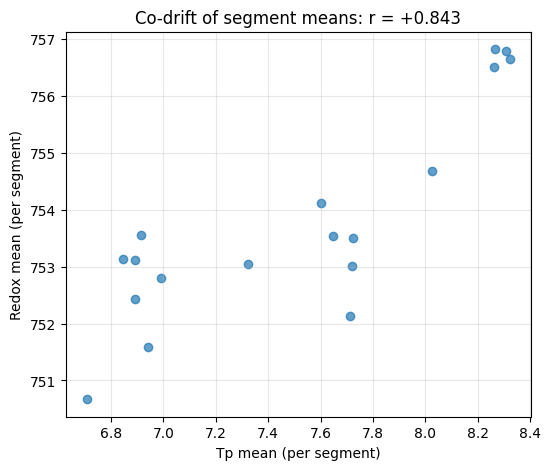

In [25]:
i_tp, j_rx = features.index('Tp'), features.index('Redox')
means_tp = np.array([seg[:, i_tp].mean() for seg in segments])
means_rx = np.array([seg[:, j_rx].mean() for seg in segments])

r = np.corrcoef(means_tp, means_rx)[0, 1]
print(f"r between per-segment means (Tp, Redox) = {r:+.3f}")

plt.figure(figsize=(6, 5))
plt.scatter(means_tp, means_rx, alpha=0.7)
plt.xlabel('Tp mean (per segment)')
plt.ylabel('Redox mean (per segment)')
plt.title(f'Co-drift of segment means: r = {r:+.3f}')
plt.grid(alpha=0.3)
plt.show()

This means GECCO has non-stationarities and thus, reinforces the per-segment approach for lag computation.

In [26]:
pairs_info = find_dominant_lagged_pairs(lagged_corrs, max_lag=max_lag)
print("Pairs with max |r(lag)| > 0.5 for a lag != 0:")
print_dominant_pairs(pairs_info, feature_names=features)

Pairs with max |r(lag)| > 0.5 for a lag != 0:
Total pairs: 36
   Redox - Cl_2    : r(0)=+0.650  r(-2)=+0.653  [pearson]
      pH - Redox   : r(0)=-0.546  r(-3)=-0.550  [pearson]
   Redox - Fm_2    : r(0)=+0.487  r(-40)=+0.494  [spearman]
      Cl - Cl_2    : r(0)=+0.179  r(+69)=+0.466  [pearson]
   Redox - Fm      : r(0)=+0.355  r(-37)=+0.368  [spearman]
      pH - Cl_2    : r(0)=-0.340  r(-6)=-0.353  [pearson]
    Leit - Fm      : r(0)=-0.263  r(-128)=-0.312  [pearson]
      Tp - Redox   : r(0)=+0.275  r(-127)=+0.292  [spearman]
      Tp - Fm      : r(0)=+0.257  r(-117)=+0.281  [spearman]
   Redox - Leit    : r(0)=-0.255  r(-30)=-0.278  [pearson]
    Leit - Fm_2    : r(0)=-0.237  r(-128)=-0.271  [spearman]
    Leit - Cl_2    : r(0)=-0.267  r(+8)=-0.269  [pearson]
      Fm - Fm_2    : r(0)=+0.229  r(+128)=+0.267  [spearman]
      Tp - Fm_2    : r(0)=+0.235  r(+126)=+0.266  [spearman]
    Cl_2 - Fm      : r(0)=+0.250  r(-21)=+0.258  [pearson]
      Cl - Redox   : r(0)=+0.060  r(+76)=+0.

## Anomaly Analysis

In [27]:
X_full = df.drop(columns=['EVENT']).values.astype(np.float64)
event = df['EVENT'].values
N, C = X_full.shape
split = N // 2
normal_all = (event == 0)

scaler = StandardScaler().fit(X_full[:split][normal_all[:split]])
X = scaler.transform(X_full)[split:]
ev = event[split:]

In [28]:
n_train = len(train_full)
n_test = len(ev)
n_anom = int(ev.sum())
dim = X.shape[1]

print(f"Dimension: {dim}")
print(f"Train Size: {n_train}")
print(f"Test (labeled): {n_test}")
print(f"Anomaly Ratio (%): {100.0 * n_anom / n_test:.2f}")

Dimension: 9
Train Size: 69260
Test (labeled): 69261
Anomaly Ratio (%): 1.05


NB: In GECCO, 996 / 69260 = 1.44% of the anomalies in the train set, which we remove.

In [29]:
df_long, df_short = classify_anomalies(X, ev, pairs_info=pairs_info)

display_cols = ['seg', 'start', 'end', 'len', 'n_dev']
for m in ['pearson', 'spearman', 'dcor']:
    display_cols += [f'd_{m}', f'lab_{m}']
print(tabulate(df_long[display_cols], headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False, missingval='-'))

summarize(df_long, df_short)

+-------+---------+-------+-------+---------+-------------+---------------+--------------+----------------+----------+------------+
|   seg |   start |   end |   len |   n_dev |   d_pearson | lab_pearson   |   d_spearman | lab_spearman   |   d_dcor | lab_dcor   |
|-------+---------+-------+-------+---------+-------------+---------------+--------------+----------------+----------+------------|
|     0 |    1650 |  1807 |   157 |       7 |       0.953 | BOTH          |        1.479 | BOTH           |    0.665 | BOTH       |
|     1 |    4982 |  5005 |    23 |       3 |       1.037 | BOTH          |        0.808 | BOTH           |    0.506 | BOTH       |
|     2 |    5248 |  5271 |    23 |       5 |       0.419 | BOTH          |        0.566 | BOTH           |    0.361 | BOTH       |
|     3 |    5538 |  5561 |    23 |       3 |       0.792 | BOTH          |        0.818 | BOTH           |    0.611 | BOTH       |
|     4 |    5811 |  5834 |    23 |       5 |       1.177 | BOTH          | 

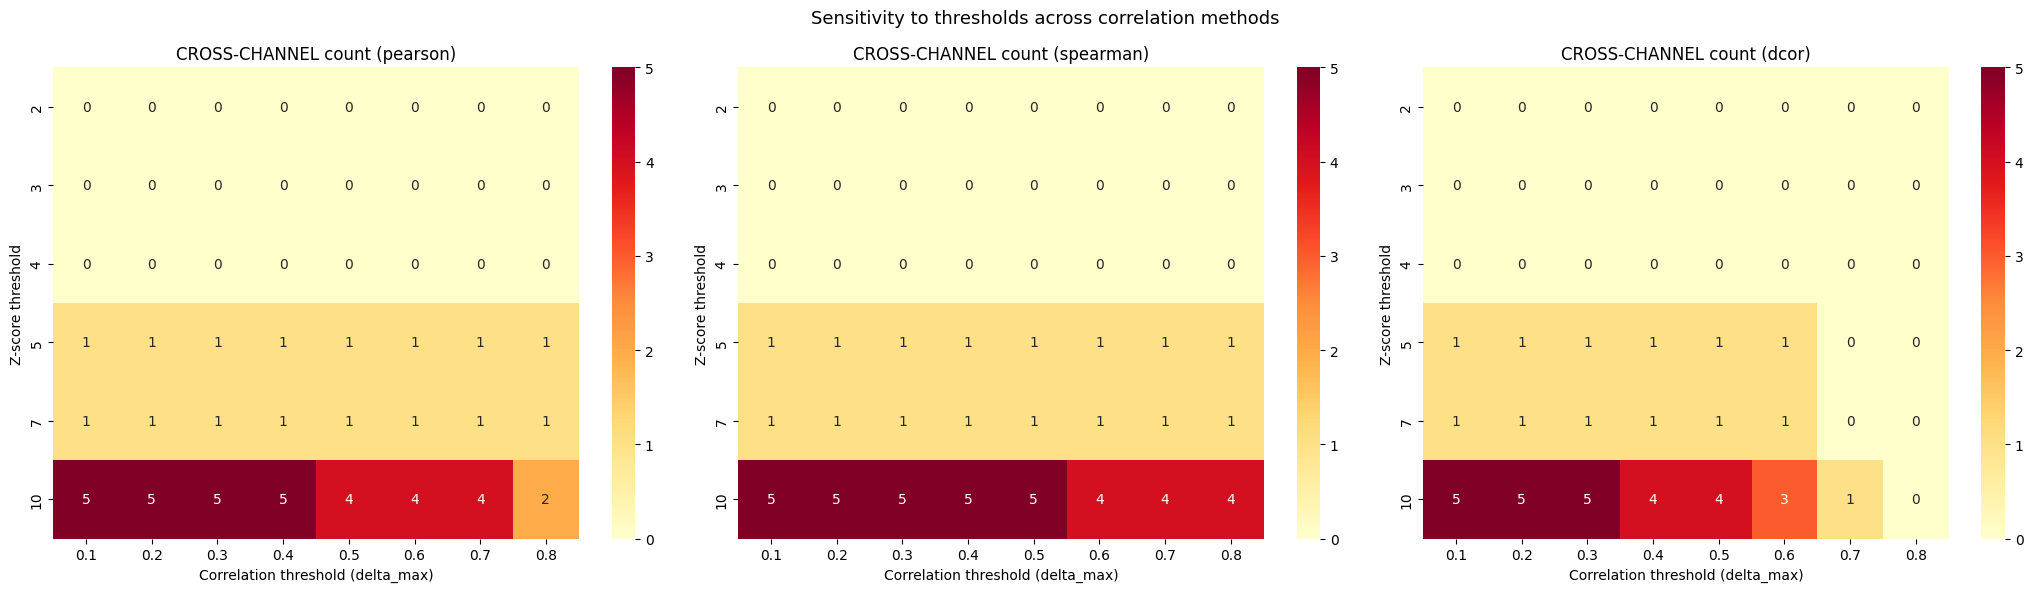

{'pearson': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [5, 5, 5, 5, 4, 4, 4, 2]]),
 'spearman': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1],
        [5, 5, 5, 5, 5, 4, 4, 4]]),
 'dcor': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [5, 5, 5, 4, 4, 3, 1, 0]])}

In [30]:
seg_stats = collect_seg_stats(X, ev, pairs_info=pairs_info)
plot_threshold_sensitivity(seg_stats, title="Sensitivity to thresholds across correlation methods")

In [31]:
normal_test = (ev == 0)
for s, e in find_contiguous_segments(ev):
    anom = X[s:e]
    ctx = preceding_normal_context(s, X, normal_test)
    if ctx is None or len(anom) < 10:
        continue
    mz = max_z_score(anom, ctx)
    md = max_delta_rho_lagged(anom, ctx, pairs_info)
    if mz <= 5 and (not np.isnan(md)) and md > 0.5:
        print(f"[{s},{e}) len={e-s} max_z={mz:.2f} delta={md:.3f}")

[7915,7938) len=23 max_z=4.71 delta=1.044


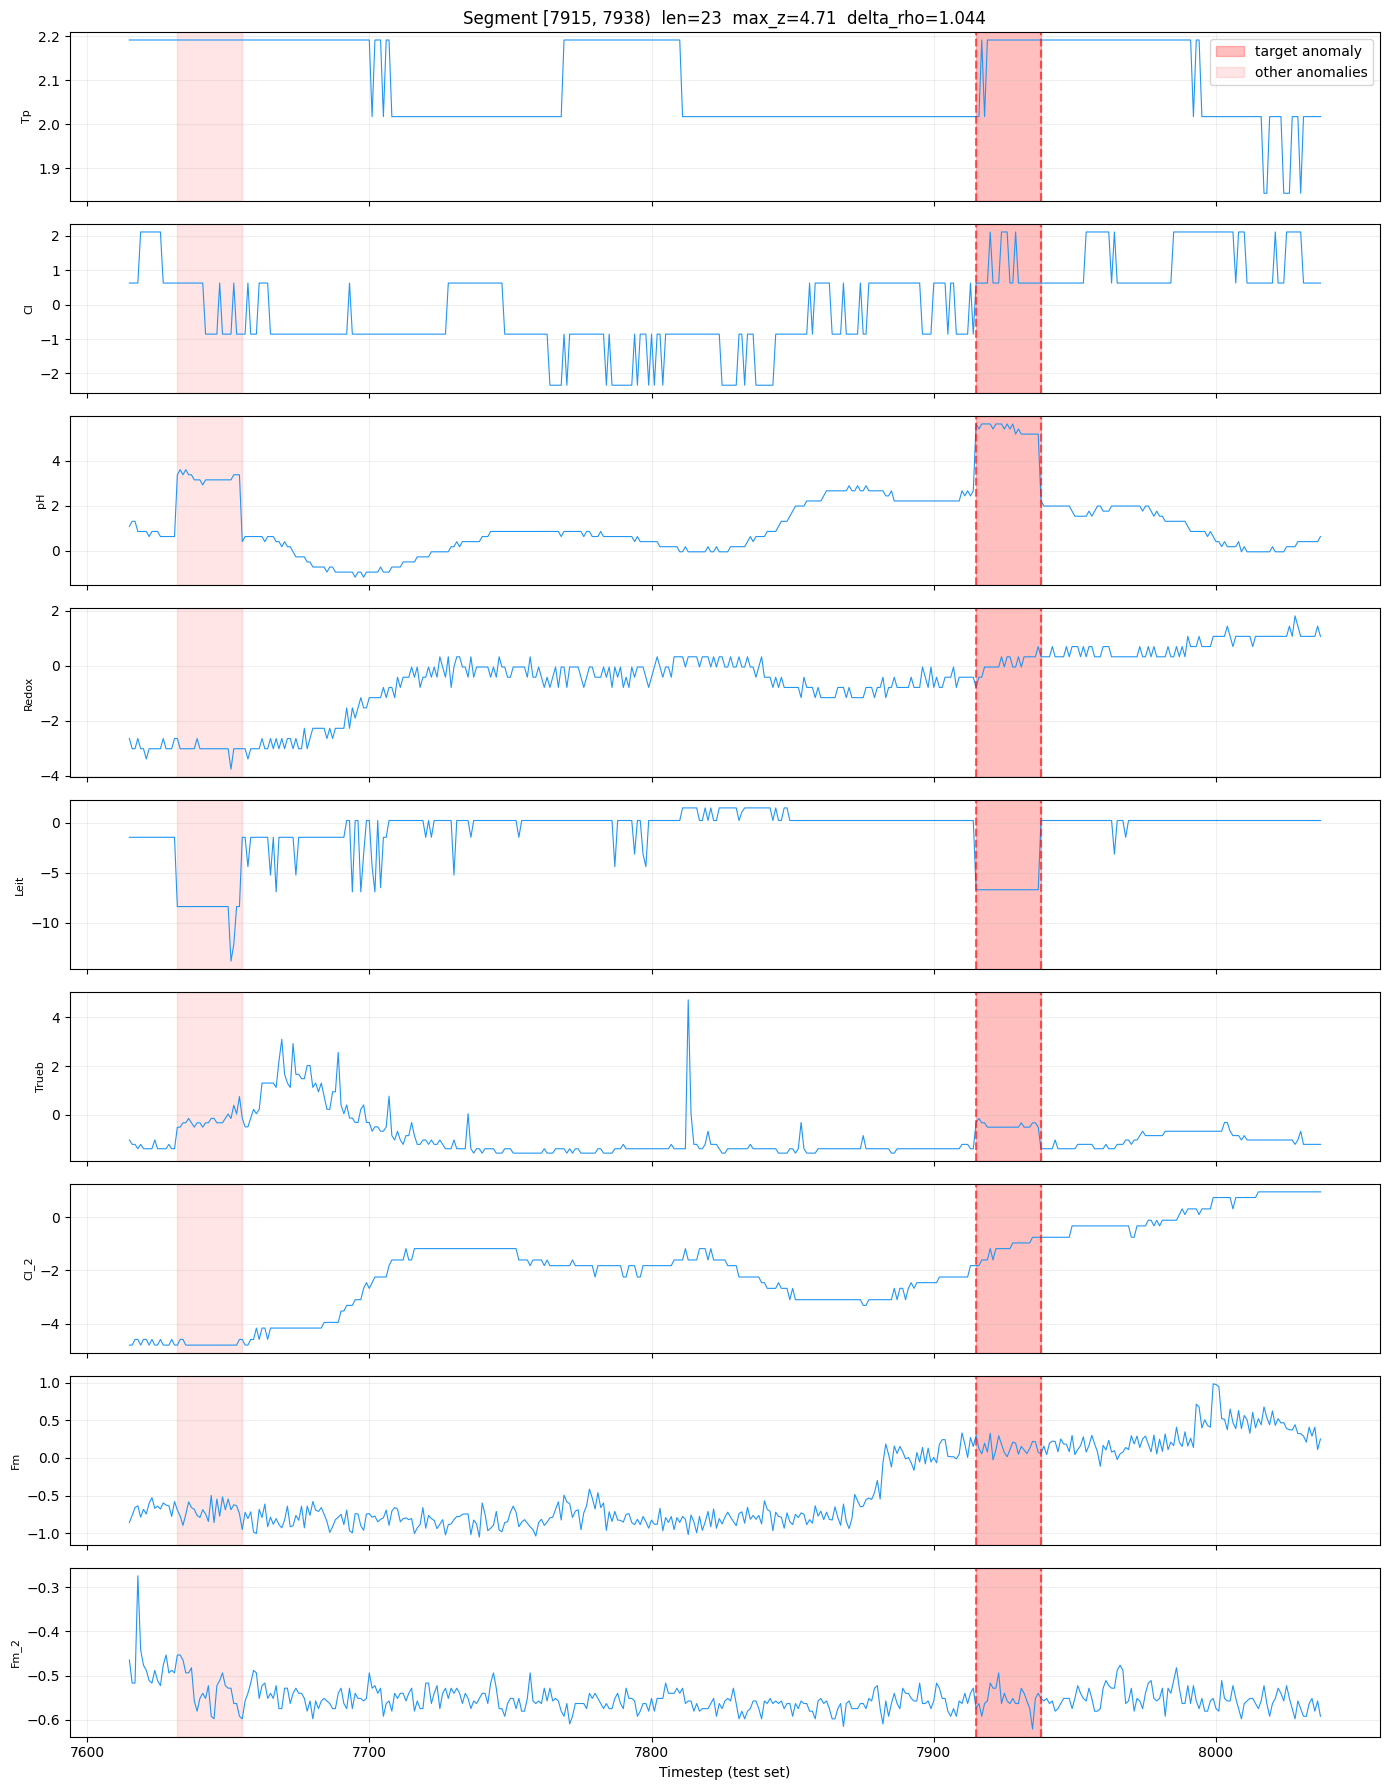

z-score per channel:
        Tp: z=1.12
        Cl: z=2.57
        pH: z=4.71
     Redox: z=1.15
      Leit: z=4.40
     Trueb: z=0.41
      Cl_2: z=1.17
        Fm: z=1.43
      Fm_2: z=0.15


In [32]:
s, e = 7915, 7938
ctx_start = max(0, s - 300)
plot_end = e + 100
feature_names = [c for c in df.columns if c != 'EVENT']
normal_test = (ev == 0)

ev_window = ev[ctx_start:plot_end]
other_segments = [
    (ctx_start + a, ctx_start + b)
    for a, b in find_contiguous_segments(ev_window)
    if not (ctx_start + a == s and ctx_start + b == e)
]

fig, axes = plt.subplots(len(feature_names), 1, figsize=(14, 2 * len(feature_names)), sharex=True)
for i, feat in enumerate(feature_names):
    ax = axes[i]
    ax.plot(range(ctx_start, plot_end), X[ctx_start:plot_end, i], linewidth=0.8, color='#2196F3')

    ax.axvspan(s, e, alpha=0.25, color='red', label='target anomaly' if i == 0 else None)
    ax.axvline(s, color='red', ls='--', alpha=0.6)
    ax.axvline(e, color='red', ls='--', alpha=0.6)

    for k, (os_, oe_) in enumerate(other_segments):
        ax.axvspan(os_, oe_, alpha=0.10, color='red', label='other anomalies' if (i == 0 and k == 0) else None)

    ax.set_ylabel(feat, fontsize=8)
    ax.grid(True, alpha=0.2)

ctx = preceding_normal_context(s, X, normal_test)
mu, sigma = ctx.mean(0), ctx.std(0)
sigma = np.where(sigma < 1e-8, 1.0, sigma)
z_per_ch = np.max(np.abs(X[s:e] - mu) / sigma, axis=0)
md = max_delta_rho_lagged(X[s:e], ctx, pairs_info)

axes[0].set_title(f"Segment [{s}, {e})  len={e-s}  max_z={z_per_ch.max():.2f}  delta_rho={md:.3f}", fontsize=12)
axes[-1].set_xlabel("Timestep (test set)")
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

print("z-score per channel:")
for i, feat in enumerate(feature_names):
    print(f"  {feat:>8s}: z={z_per_ch[i]:.2f}")

(Light-red) Anomaly in the time serie but it's not the one we want to visualize<br>
(Bold-red) Current anomaly segment evaluted, we see that it's almost trivial when using only the pH or Leit channel

In [33]:
intensity_df, summary = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev], names=['gecco'],
)
print(tabulate(summary, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       22.000 |            0.973 |              1.000 |           0.724 |
+--------------+------------------+--------------------+-----------------+


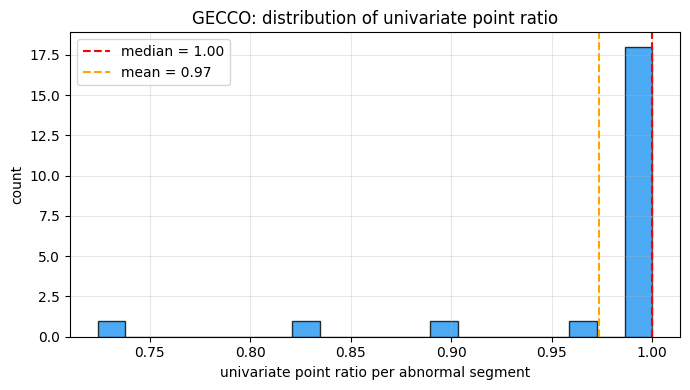

In [34]:
plot_univariate_intensity_distribution(intensity_df, 'GECCO')

Number of BOTH segments (union over pearson/spearman/dcor): 22
Anomalous points retained: 730 / 730 (100.0%)
+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       22.000 |            0.973 |              1.000 |           0.724 |
+--------------+------------------+--------------------+-----------------+


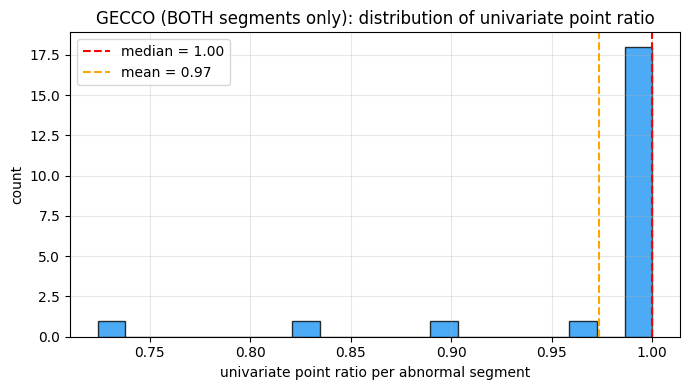

In [35]:
both_mask = (
    (df_long['lab_pearson'] == 'BOTH') |
    (df_long['lab_spearman'] == 'BOTH') |
    (df_long['lab_dcor'] == 'BOTH')
)
both_segments = df_long.loc[both_mask, ['start', 'end']].astype(int).values

ev_both = np.zeros_like(ev)
for s, e in both_segments:
    ev_both[s:e] = 1

print(f"Number of BOTH segments (union over pearson/spearman/dcor): {len(both_segments)}")
print(f"Anomalous points retained: {int(ev_both.sum())} / {int(ev.sum())} "f"({100.0 * ev_both.sum() / max(ev.sum(), 1):.1f}%)")

intensity_df_both, summary_both = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev_both], names=['gecco_both'],
)
print(tabulate(summary_both, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

plot_univariate_intensity_distribution(intensity_df_both, 'GECCO (BOTH segments only)')

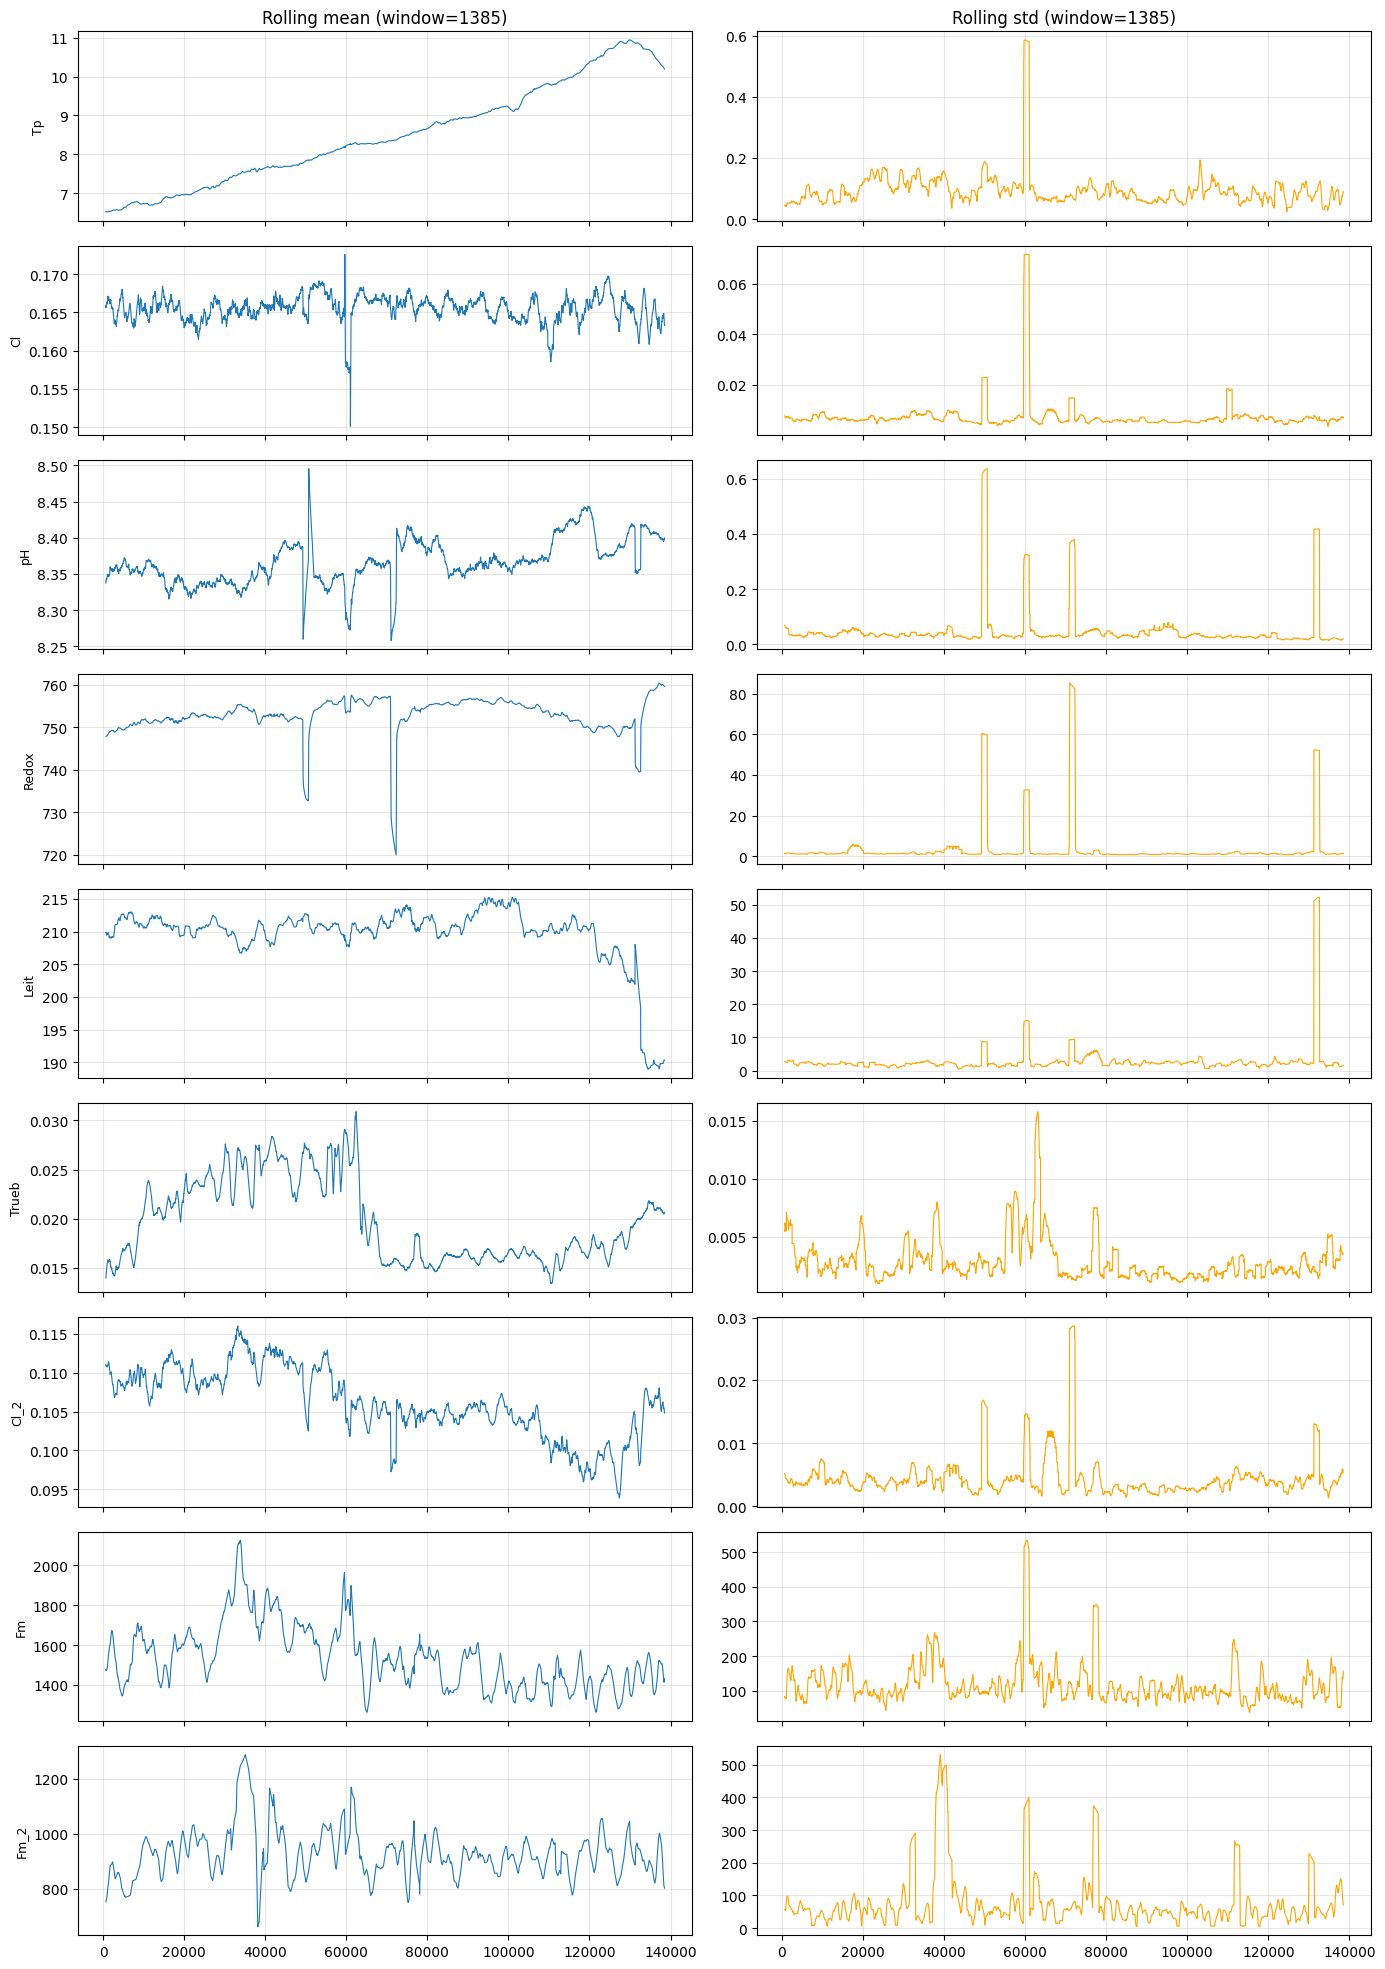

In [36]:
features = [c for c in df.columns if c != 'EVENT']
X = df[features].values.astype(np.float64)
N, C = X.shape

window = max(N // 100, 500)

fig, axes = plt.subplots(C, 2, figsize=(14, 2.2 * C), sharex=True)
for i, feat in enumerate(features):
    s = pd.Series(X[:, i])
    roll_mean = s.rolling(window, min_periods=window // 2).mean()
    roll_std = s.rolling(window, min_periods=window // 2).std()

    axes[i, 0].plot(roll_mean.values, linewidth=0.8)
    axes[i, 0].set_ylabel(feat, fontsize=9)
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(roll_std.values, linewidth=0.8, color='orange')
    axes[i, 1].grid(alpha=0.3)

axes[0, 0].set_title(f'Rolling mean (window={window})')
axes[0, 1].set_title(f'Rolling std (window={window})')
plt.tight_layout()
plt.show()